In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# generate linearly seperable data
x,y= make_classification(
    n_samples= 200,
    n_features= 2,
    n_redundant= 0,
    n_clusters_per_class= 1,
    random_state= 42

)
print (x,y)

[[-0.87292898  0.013042  ]
 [ 1.31293463  2.77053357]
 [ 2.34042818  2.42099601]
 [ 2.29454774 -0.40438019]
 [ 0.94410516  0.4772409 ]
 [-0.11959689  0.50891314]
 [ 0.1510847   0.81007677]
 [-0.00745441 -0.45284256]
 [-1.25396925  0.06769236]
 [-0.24392415  1.19979806]
 [-1.9208928   2.9189499 ]
 [ 0.48806269  3.50578584]
 [ 2.25751204  1.81515089]
 [-3.12190908  0.62220145]
 [ 1.87768113  0.51095984]
 [ 0.46785542  0.7871928 ]
 [ 0.48404809  0.04843842]
 [-0.54235518  3.49536942]
 [ 1.04235818  1.10204918]
 [ 1.63367133  0.59219328]
 [ 1.85756778  1.7382647 ]
 [-2.41167954 -0.80620914]
 [ 0.87481918  0.48815664]
 [ 0.09529002  0.57526555]
 [-1.64994223 -0.06695917]
 [-0.65245349 -0.19158949]
 [ 2.10252081  2.34684404]
 [ 2.9574463   2.01418031]
 [-1.70056309 -0.19333846]
 [ 0.86204356  0.66498993]
 [ 0.30162791  0.22791173]
 [ 1.96734507  1.82610109]
 [-0.6910389   0.46491472]
 [ 3.66332221  2.15367981]
 [ 2.3487899   2.70680122]
 [-0.10191136  2.4621975 ]
 [-1.09936351  1.47691125]
 

In [ ]:
#split into training and test sets
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3,
                                                   random_state=42)

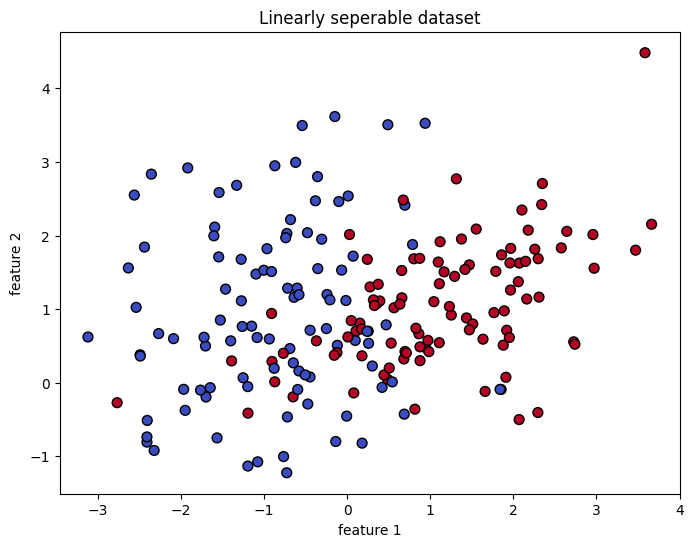

In [ ]:
#visualize the datasets
plt.figure(figsize=(8,6))
plt.scatter(x[:,0],x[:,1], c=y, cmap=plt.cm.coolwarm, s=50,edgecolors='k')
plt.title("Linearly seperable dataset")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#create and train linear SVM
linear_svm=SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(x_train, y_train)

#make predictions
y_pred= linear_svm.predict(x_test)


In [ ]:
#evaluate performamce
print(f" Accuracy:{accuracy_score(y_test, y_pred):.4f}")
print("\n classification Report")
print(classification_report(y_test, y_pred))
print("\n Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

 Accuracy:0.8667

 classification Report
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        34
           1       0.80      0.92      0.86        26

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60


 Confusion Matrix
[[28  6]
 [ 2 24]]


In [ ]:
def plot_decision_boundary(clf,x,y):

  # create a mesh to plot in
  h=0.02 #step size in the mesh
  x_mim, x_max= x[:,0].min()-1, x[:,0].max()+1
  y_mim, y_max= x[:,1].min()-1, x[:,1].max()+1
  xx,yy =np.meshgrid(np.arange(x_mim, x_max,h), np.arange(y_mim, y_max,h))

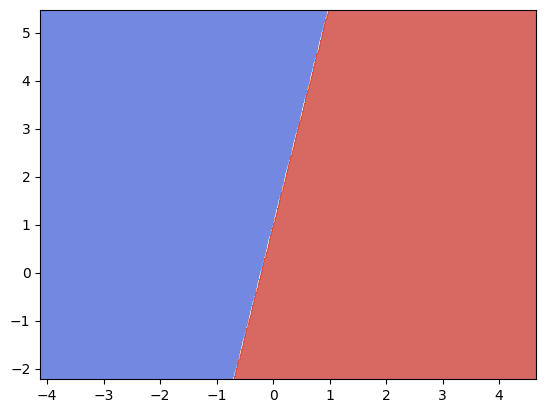

In [ ]:
#plot the decision boundary
# create a mesh to plot in
h = 0.02 #step size in the mesh
x_min, x_max = x[:,0].min()-1, x[:,0].max()+1
y_min, y_max = x[:,1].min()-1, x[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

z = linear_svm.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
plt.contourf(xx, yy, z, alpha=0.8, cmap=plt.cm.coolwarm)

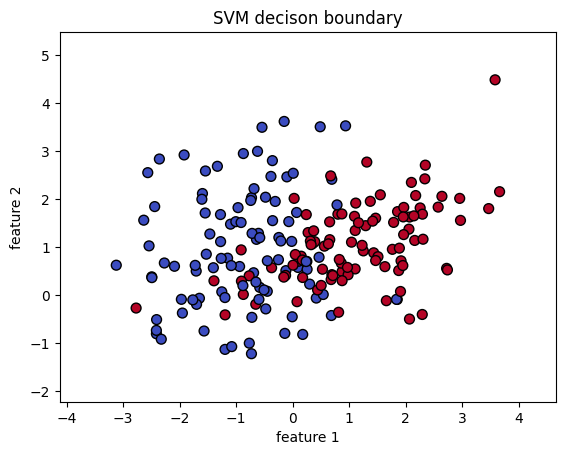

In [ ]:
#plot the training points
plt.scatter(x[:,0], x[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=50)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("SVM decison boundary")
plt.show()

In [ ]:
plot_decision_boundary(linear_svm, x_train, y_train)

In [ ]:
#create and train linear SVM
rbf_svm= SVC(kernel='rbf')
rbf_svm.fit(x_train,y_train)
#make predictions on the

#make predictions
y_pred= rbf_svm.predict(x_test)



In [ ]:
#evaluate performamce
print(f" Accuracy:{accuracy_score(y_test, y_pred):.4f}")
print("\n classification Report")
print(classification_report(y_test, y_pred))
print("\n Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

 Accuracy:0.8500

 classification Report
              precision    recall  f1-score   support

           0       0.93      0.79      0.86        34
           1       0.77      0.92      0.84        26

    accuracy                           0.85        60
   macro avg       0.85      0.86      0.85        60
weighted avg       0.86      0.85      0.85        60


 Confusion Matrix
[[27  7]
 [ 2 24]]


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=pd.read_csv("/content/sample_data/IRIS.csv")
df= pd.DataFrame(iris)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Features (X) head:")
display(X.head())
print("\nTarget (y_encoded) head:")
display(y_encoded[:5])
print("\nEncoded labels:", label_encoder.classes_)

Features (X) head:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y_encoded) head:


array([0, 0, 0, 0, 0])


Encoded labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:

from sklearn.preprocessing import StandardScaler, LabelEncoder

x= df_csv.drop('species', axis=1)
y= df_csv['species']

NameError: name 'df_csv' is not defined

In [ ]:
#create a function to transform the data
import numpy as np
def PCA(x, num_components):
  #step-1
  x_meaned=x-np.mean(x, axis=0)
  #setp-2
  cov_mat=np.cov(x_meaned, rowvar=False)
  #step-3
  eigen_values, eigen_vectors= np.linalg.eigh(cov_mat)
  #step-4
  sorted_index=np.argsort(eigen_values)[::-1]
  sorted_eigenvalues=eigen_values[sorted_index]
  sorted_eigenvectors=eigen_vectors[:,sorted_index]
  #step-5
  eigenvector_subset= sorted_eigenvectors[:,0:num_components]

  #step-6
  x_reduced= np.dot(eigenvector_subset.transpose(), x_meaned.transpose()).transpose()

  return x_reduced
  print(x_reduced)

In [ ]:
# Apply PCA to the Iris features
pca_iris_data = PCA(X, num_components=2)

In [ ]:
# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_iris_data, columns=['PC1', 'PC2'])
pca_df['species'] = y_encoded # Add the encoded species for visualization

print("PCA Transformed Iris Data (first 5 rows):")
display(pca_df.head())

PCA Transformed Iris Data (first 5 rows):


,PC1,PC2,species
0,2.684207,0.326607,0
1,2.715391,-0.169557,0
2,2.889820,-0.137346,0
3,2.746437,-0.311124,0
4,2.728593,0.333925,0


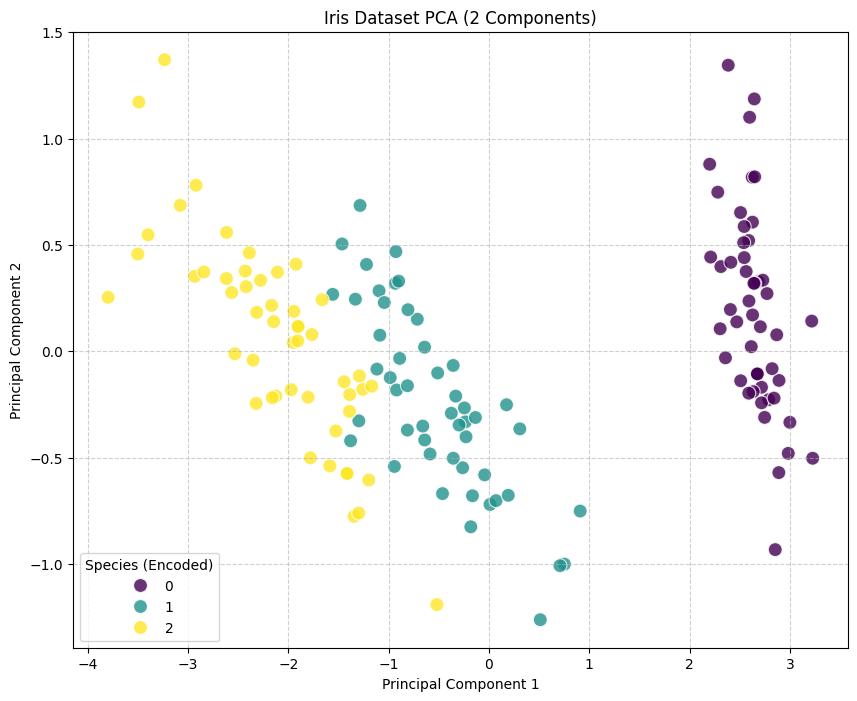

In [ ]:
# Visualize the PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='species',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Iris Dataset PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Species (Encoded)')
plt.show()